# Estimation

This notebook estimates the job-search model

**Order of estimation**
1. L-BFGS-B: Standard 1-type, Standard 2-type, Standard 3-type, Reference-dependent 1-type.
2. LS-TRF: Standard 1-type, Standard 2-type, Standard 3-type, Reference-dependent 1-type.

For the **standard model**, `eta = 0` and `lambda = 0` are fixed. We estimate `delta`, `gamma`, the relevant search-cost parameters `k`, and the type shares `q`. `N` is fixed.

For the **reference-dependent model**, we use one type and estimate `delta`, `gamma`, `eta`, `k`, and `lambda`, while keeping `N` fixed.

This notebook produces:
- initial-fit and post-estimation hazard plots;
- estimation tables in both DataFrame and LaTeX form;
- goodness of fit (SSE);
- elapsed estimation time;
- a type-survival / survivor-composition for heterogeneous-type models.

## 1. Setup

Set `MODEL_DIR` to the folder containing `Model_components.py` if needed. The code below uses the same local path as the existing notebook by default.

In [15]:
# magics: ensures that any changes to the modules loaded below will be re-loaded automatically
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import os
import sys
import time

import numpy as np
from time import process_time
import matplotlib.pyplot as plt
from scipy import interpolate 
import optimagic as om
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import pandas as pd
import scipy.optimize as opt
from scipy.optimize import fsolve
from scipy.stats import beta


MODEL_DIR = os.environ.get(
    "JOB_SEARCH_MODEL_DIR",
    "C:\\Users\\jap\\OneDrive - ROCKWOOL FONDEN\\Python Workspace\\termpaper_dynprog\\Job Search\\"
)

MODEL_DIR = os.environ.get(
    "JOB_SEARCH_MODEL_DIR",
    '/Users/albertolsen/Documents/Stud Polit/9. semester/Dynamic Programming/Exam/termpaper_dynprog/Job Search'
)



if MODEL_DIR not in sys.path:
    sys.path.append(MODEL_DIR)

import Model_components_copy as model

FIGURE_DIR = os.path.join(os.getcwd(), "estimation_figures")
TABLE_DIR = os.path.join(os.getcwd(), "estimation_tables")
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.5f}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


## 2. Parameters and institutions

The computational asset grid and the initial asset distribution are separate objects. `abar` controls the state space; `weights` controls how initial asset states are represented in the simulated population.

For faster exploratory estimation, reduce `n_a` and/or `n_c`. Re-solve the final estimates on a finer grid as a robustness check.

In [16]:
# Baseline structural values / starting values
delta = 0.89
gamma = 0.81
eta_rd = 1.0
beta = 0.8

k = 359.0
k1 = 300.0
k2 = 150.0
k3 = 90.0

q1 = 0.33
q2 = 0.33

lmbda_rd = 4.9
N = 6

# Asset state space
abar = [0, 17955]

# Grid sizes
n_a = 50
n_c = 100

# Timing
T1 = 6
T2 = 18
T3 = 24
T = 44

# Pre-reform benefits
b1_pre = 222
b2_pre = 222
b3 = 114

# Post-reform benefits
b1_post = 342
b2_post = 171

welfare = 90
w = 675
R = 0.01

# 0 = heterogeneous assets; 1 = hand-to-mouth
htm = 0

institutions_pre = np.array([
    n_a, n_c, T1, T2, T3, T,
    b1_pre, b2_pre, b3, welfare, w, R
])

institutions_post = np.array([
    n_a, n_c, T1, T2, T3, T,
    b1_post, b2_post, b3, welfare, w, R
])

weights = model.make_weights(htm, abar, n_a)

target, cov = model.matchingMoments()
W = np.linalg.inv(cov)

# matchingMoments() drops the first empirical 15-day moment.
# Hence 35 retained observations correspond to days 30,...,540.
timevec = np.arange(15, 526, 15)

def split_half(arr):
    arr = np.asarray(arr)
    mid = len(arr) // 2
    return arr[:mid], arr[mid:]

emp_pre, emp_post = split_half(target)

print("Number of moments:", len(target))
print("Asset weights sum to:", weights.sum())

Number of moments: 70
Asset weights sum to: 1.0000000000000002


## 3. Model specifications

The parameter vectors must match the ordering expected by `SolveMultiTypeModel`.

- Standard 1 type: `[delta, gamma, 0, k1, 0, N]`
- Standard 2 type: `[delta, gamma, 0, k1, 0, N, k2, q1]`
- Standard 3 type: `[delta, gamma, 0, k1, 0, N, k2, k3, q1, q2]`
- RD 1 type: `[delta, gamma, eta, k1, lambda, N]`

For the 3-type model, the current model defines the third share as `1 - q1 - q2`. The box bounds below keep `q1 + q2 < 1` throughout optimization.

In [17]:
def make_specs():
    specs = {}

    specs["Reference dependent 1 type"] = {
        "full": pd.DataFrame(
            {"value": [delta, gamma, eta_rd, k, lmbda_rd, N]},
            index=["delta", "gamma", "eta", "k1", "lmbda", "N"]
        ),
        "free": pd.DataFrame(
            {
                "value": [delta, gamma, eta_rd, k, lmbda_rd],
                "lower_bound": [0.01, 1e-2, 0.01, 1e-5, 0.01],
                "upper_bound": [0.95, 2.0, 15.0, 2000.0, 15.0],
            },
            index=["delta", "gamma", "eta", "k1", "lmbda"]
        ),
    }

    specs["RD - beta value"] = {
        "full": pd.DataFrame(
            {"value": [delta, beta, gamma, eta_rd, k, lmbda_rd, N]},
            index=["delta","beta",  "gamma", "eta", "k1", "lmbda", "N"]
        ),
        "free": pd.DataFrame(
            {
                "value": [delta, beta, gamma, eta_rd, k, lmbda_rd],
                "lower_bound": [0.01, 0.01 ,1e-2, 0.01, 1e-5, 0.01],
                "upper_bound": [0.95, 0.99 ,2.0, 15.0, 2000.0, 15.0],
            },
            index=["delta", "beta",  "gamma", "eta", "k1", "lmbda"]
        ),
    }

    return specs

specs = make_specs()

for name, spec in specs.items():
    print(name)
    display(spec["free"])

Reference dependent 1 type


,value,lower_bound,upper_bound
delta,0.89000,0.01000,0.95000
gamma,0.81000,0.01000,2.00000
eta,1.00000,0.01000,15.00000
k1,359.00000,0.00001,"2,000.00000"
lmbda,4.90000,0.01000,15.00000


RD - beta value


,value,lower_bound,upper_bound
delta,0.89000,0.01000,0.95000
beta,0.80000,0.01000,0.99000
gamma,0.81000,0.01000,2.00000
eta,1.00000,0.01000,15.00000
k1,359.00000,0.00001,"2,000.00000"
lmbda,4.90000,0.01000,15.00000


## 4. Helper functions
These functions makes the estimation much more neat and does the following
- Create a vector of the values of the estimated parameters + those that were fixed
- Create a vector of initial values to input in the estimation
- Simulate moments (only need to input the parameters dependent on model type)
- Plot the simulated/estimated moments against the empirical moments
- Run the estimation (only need to input model name and estimation algorithm)
- Output estimation results, algorithm used, model used, SSE (goodness of fit), time it took for the estimation for a table

*** Note ***
`L-BFGS-B` uses the SSE criterion. `LS-TRF` uses the residual-vector criterion (cholesky decomposition) because it is a least-squares algorithm.



In [18]:
def full_vector_from_result(spec, result):
    full = spec["full"].copy()
    full.update(result.params)
    return full["value"].to_numpy()


def initial_vector(spec):
    return spec["full"]["value"].to_numpy().copy()


def simulate_fit(params_vec):
    moments = model.simulate_moments(
        params_vec,
        institutions_pre,
        institutions_post,
        abar,
        weights,
        htm,
    )
    return split_half(moments)


def plot_fit(params_vec, title, filename=None):
    pred_pre, pred_post = simulate_fit(params_vec)

    

    plt.plot(timevec, emp_pre, marker=".", label="Empirical pre-reform",  color='tab:blue')
    plt.plot(timevec, emp_post, marker=".", label="Empirical post-reform",  color='tab:red')
    plt.plot(timevec, pred_pre, linestyle="--", label="Model pre-reform", color='tab:blue')
    plt.plot(timevec, pred_post, linestyle="--", label="Model post-reform", color='tab:red')

    plt.vlines(x=[(T1)*15, (T2)*15, (T3)*15], ymin=0, ymax=0.1, colors='black', linestyles='dashed')

    plt.xlabel("Number of days since UI claim")
    plt.ylabel("Hazard rate")
    plt.title(title)
    plt.xlim(0, 560)
    plt.ylim(0, 0.1)
    plt.xticks(np.arange(0, 541, 90))
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    

    if filename is not None:
        plt.savefig(os.path.join(FIGURE_DIR, filename), bbox_inches="tight")

    plt.show()
    


def run_estimation(model_name, algorithm):
    spec = specs[model_name]

    smm_object = model.smm(
        spec["full"].copy(),
        target,
        W,
        institutions_pre,
        institutions_post,
        abar,
        weights,
        htm,
    )

    if algorithm == "scipy_lbfgsb":
        criterion = smm_object.sse
    elif algorithm == "scipy_ls_trf":
        criterion = smm_object.criterion
    else:
        raise ValueError("Unsupported algorithm.")

    start = time.perf_counter()

    result = om.minimize(
        criterion=criterion,
        params=spec["free"].copy(),
        algorithm=algorithm,
    )

    elapsed = time.perf_counter() - start

    params_hat = full_vector_from_result(spec, result)

    # Compute the same quadratic SSE for all algorithms for direct comparison.
    sse_hat = model.sse(
        params_hat,
        target,
        W,
        institutions_pre,
        institutions_post,
        abar,
        weights,
        htm,
    )

    return {
        "model": model_name,
        "algorithm": algorithm,
        "result": result,
        "params_hat": params_hat,
        "sse": float(sse_hat),
        "seconds": elapsed,
        "full_index": list(spec["full"].index),
    }


def result_row(out):
    values = dict(zip(out["full_index"], out["params_hat"]))
    return {
        "Algorithm": out["algorithm"],
        "Model": out["model"],
        "delta": values.get("delta", np.nan),
        "gamma": values.get("gamma", np.nan),
        "eta": values.get("eta", np.nan),
        "lambda": values.get("lmbda", np.nan),
        "k1": values.get("k1", np.nan),
        "k2": values.get("k2", np.nan),
        "k3": values.get("k3", np.nan),
        "q1": values.get("q1", np.nan),
        "q2": values.get("q2", np.nan),
        "q3": (
            1 - values.get("q1", 0) - values.get("q2", 0)
            if "q2" in values else
            (1 - values.get("q1", 0) if "q1" in values else np.nan)
        ),
        "SSE": out["sse"],
        "Minutes": out["seconds"] / 60,
    }


results = {}

## 5.5 Estimation Table 1 (L-BFGS-B)

The LaTeX table is printed in the notebook and also saved to `estimation_tables/lbfgsb_results.tex`.

In [19]:
lbfgsb_table = pd.DataFrame([
    result_row(results[("L-BFGS-B", name)])
    for name in specs.keys()
])

display(lbfgsb_table)

lbfgsb_latex = lbfgsb_table.to_latex(
    index=False,
    float_format=lambda x: f"{x:.4f}",
    na_rep="--",
    caption="SMM estimates using L-BFGS-B.",
    label="tab:lbfgsb_estimates",
)

print(lbfgsb_latex)

with open(os.path.join(TABLE_DIR, "lbfgsb_results.tex"), "w", encoding="utf-8") as f:
    f.write(lbfgsb_latex)

KeyError: ('L-BFGS-B', 'Reference dependent 1 type')

## 1. Normal RD model

In [6]:
results[("LS-TRF", 'Reference dependent 1 type')] = run_estimation(
    'Reference dependent 1 type',
    "scipy_ls_trf"
)

out = results[("LS-TRF", 'Reference dependent 1 type')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

/opt/anaconda3/lib/python3.12/site-packages/optimagic/deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)
/opt/anaconda3/lib/python3.12/site-packages/optimagic/deprecations.py:333: FutureWarning: Returning a dictionary with the special keys 'value', 'contributions', or 'root_contributions' is deprecated and will be removed in optimagic version 0.6.0 and later. Please use the optimagic.mark.scalar, optimagic.mark.least_squares, or optimagic.mark.likelihood decorators to indicate the type of problem you are solving. Use optimagic.FunctionValue objects to return additional information for the logging. Please see the documentation for more details: https://optimagic.readthedocs.io/en/latest/how_to/how_to_criterion_function.html
  warnings.warn(msg, FutureWarning)


Estimated parameters: [  0.94999115   0.92545306   1.38424859 894.31404356  14.99342324
   6.        ]
SSE: 126.520882
Elapsed: 0.96 minutes


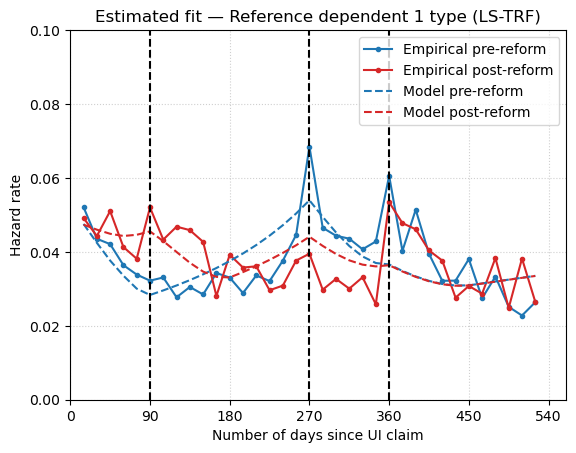

In [7]:
plot_fit(
    results[("LS-TRF", 'Reference dependent 1 type')]["params_hat"],
    'Estimated fit — Reference dependent 1 type (LS-TRF)',
    'lstrf_rd1_after.pdf',
)

## 2. RD model with present bias

In [20]:
results[("LS-TRF", 'RD - beta value')] = run_estimation(
    'RD - beta value',
    "scipy_ls_trf"
)

out = results[("LS-TRF", 'RD - beta value')]
print("Estimated parameters:", out["params_hat"])
print(f"SSE: {out['sse']:.6f}")
print(f"Elapsed: {out['seconds']/60:.2f} minutes")

/opt/anaconda3/lib/python3.12/site-packages/optimagic/deprecations.py:53: FutureWarning: To align optimagic with scipy.optimize, the `criterion` argument has been renamed to `fun`. Please use `fun` instead of `criterion`. Using `criterion`  will become an error in optimagic version 0.6.0 and later.
  warnings.warn(msg, FutureWarning)


InvalidFunctionError: Error while evaluating fun at start params.

## 6.5 Estimation Table 2 (LS-TRF)

In [ ]:
lstrf_table = pd.DataFrame([
    result_row(results[("LS-TRF", name)])
    for name in specs.keys()
])

display(lstrf_table)

lstrf_latex = lstrf_table.to_latex(
    index=False,
    float_format=lambda x: f"{x:.4f}",
    na_rep="--",
    caption="SMM estimates using LS-TRF.",
    label="tab:lstrf_estimates",
)

print(lstrf_latex)

with open(os.path.join(TABLE_DIR, "lstrf_results.tex"), "w", encoding="utf-8") as f:
    f.write(lstrf_latex)

,Algorithm,Model,delta,gamma,eta,lambda,k1,k2,k3,q1,q2,q3,SSE,Minutes
0,scipy_ls_trf,Standard 1 type,0.91676,0.92672,0.00000,0.00000,315.82581,NaN,NaN,NaN,NaN,NaN,578.55749,1.97433
1,scipy_ls_trf,Standard 2 type,0.82785,1.36318,0.00000,0.00000,899.93787,35.91790,NaN,0.75110,NaN,0.24890,96.62646,12.06254
2,scipy_ls_trf,Standard 3 type,0.77680,1.28588,0.00000,0.00000,730.85371,200.33919,16.69599,0.48989,0.31966,0.19045,94.68896,9.35979
3,scipy_ls_trf,Reference dependent 1 type,0.94999,0.92545,1.38425,14.99342,894.31292,NaN,NaN,NaN,NaN,NaN,126.52089,3.17977


\begin{table}
\caption{SMM estimates using LS-TRF.}
\label{tab:lstrf_estimates}
\begin{tabular}{llrrrrrrrrrrrr}
\toprule
Algorithm & Model & delta & gamma & eta & lambda & k1 & k2 & k3 & q1 & q2 & q3 & SSE & Minutes \\
\midrule
scipy_ls_trf & Standard 1 type & 0.9168 & 0.9267 & 0.0000 & 0.0000 & 315.8258 & -- & -- & -- & -- & -- & 578.5575 & 1.9743 \\
scipy_ls_trf & Standard 2 type & 0.8278 & 1.3632 & 0.0000 & 0.0000 & 899.9379 & 35.9179 & -- & 0.7511 & -- & 0.2489 & 96.6265 & 12.0625 \\
scipy_ls_trf & Standard 3 type & 0.7768 & 1.2859 & 0.0000 & 0.0000 & 730.8537 & 200.3392 & 16.6960 & 0.4899 & 0.3197 & 0.1904 & 94.6890 & 9.3598 \\
scipy_ls_trf & Reference dependent 1 type & 0.9500 & 0.9255 & 1.3842 & 14.9934 & 894.3129 & -- & -- & -- & -- & -- & 126.5209 & 3.1798 \\
\bottomrule
\end{tabular}
\end{table}



# 7. Estimator comparison

This table puts the two optimizers side by side for a comparison of parameter stability, goodness of fit, and runtime.

In [ ]:
combined_table = pd.concat(
    [lbfgsb_table, lstrf_table],
    ignore_index=True
).sort_values(["Model", "Algorithm"])

display(combined_table)

combined_latex = combined_table.to_latex(
    index=False,
    float_format=lambda x: f"{x:.4f}",
    na_rep="--",
    caption="SMM estimates across model specifications and optimization algorithms.",
    label="tab:all_estimates",
)

print(combined_latex)

with open(os.path.join(TABLE_DIR, "all_estimates.tex"), "w", encoding="utf-8") as f:
    f.write(combined_latex)

,Algorithm,Model,delta,gamma,eta,lambda,k1,k2,k3,q1,q2,q3,SSE,Minutes
3,scipy_lbfgsb,Reference dependent 1 type,0.95000,0.66311,1.07307,13.87022,358.51467,NaN,NaN,NaN,NaN,NaN,133.36761,31.15202
7,scipy_ls_trf,Reference dependent 1 type,0.94999,0.92545,1.38425,14.99342,894.31292,NaN,NaN,NaN,NaN,NaN,126.52089,3.17977
0,scipy_lbfgsb,Standard 1 type,0.91381,0.97702,0.00000,0.00000,358.19481,NaN,NaN,NaN,NaN,NaN,559.74142,11.72907
4,scipy_ls_trf,Standard 1 type,0.91676,0.92672,0.00000,0.00000,315.82581,NaN,NaN,NaN,NaN,NaN,578.55749,1.97433
1,scipy_lbfgsb,Standard 2 type,0.94221,0.72519,0.00000,0.00000,300.03636,150.52343,NaN,0.60479,NaN,0.39521,517.72982,51.26212
5,scipy_ls_trf,Standard 2 type,0.82785,1.36318,0.00000,0.00000,899.93787,35.91790,NaN,0.75110,NaN,0.24890,96.62646,12.06254
2,scipy_lbfgsb,Standard 3 type,0.90327,0.79512,0.00000,0.00000,397.62695,138.62773,18.25851,0.35156,0.42486,0.22359,95.52158,109.38387
6,scipy_ls_trf,Standard 3 type,0.77680,1.28588,0.00000,0.00000,730.85371,200.33919,16.69599,0.48989,0.31966,0.19045,94.68896,9.35979


\begin{table}
\caption{SMM estimates across model specifications and optimization algorithms.}
\label{tab:all_estimates}
\begin{tabular}{llrrrrrrrrrrrr}
\toprule
Algorithm & Model & delta & gamma & eta & lambda & k1 & k2 & k3 & q1 & q2 & q3 & SSE & Minutes \\
\midrule
scipy_lbfgsb & Reference dependent 1 type & 0.9500 & 0.6631 & 1.0731 & 13.8702 & 358.5147 & -- & -- & -- & -- & -- & 133.3676 & 31.1520 \\
scipy_ls_trf & Reference dependent 1 type & 0.9500 & 0.9255 & 1.3842 & 14.9934 & 894.3129 & -- & -- & -- & -- & -- & 126.5209 & 3.1798 \\
scipy_lbfgsb & Standard 1 type & 0.9138 & 0.9770 & 0.0000 & 0.0000 & 358.1948 & -- & -- & -- & -- & -- & 559.7414 & 11.7291 \\
scipy_ls_trf & Standard 1 type & 0.9168 & 0.9267 & 0.0000 & 0.0000 & 315.8258 & -- & -- & -- & -- & -- & 578.5575 & 1.9743 \\
scipy_lbfgsb & Standard 2 type & 0.9422 & 0.7252 & 0.0000 & 0.0000 & 300.0364 & 150.5234 & -- & 0.6048 & -- & 0.3952 & 517.7298 & 51.2621 \\
scipy_ls_trf & Standard 2 type & 0.8278 & 1.3632 & 0.0000 & 